# Feature Value Attribution Analysis

This notebook analyzes **which specific feature values** receive high or low attributions.

For categorical features (Activity, Resource, Customer, Variant Index), we break down:
- Which specific values (e.g., which activities) get high attributions?
- Which values get low attributions?
- How does this vary by prediction quality?

This helps understand what the model "pays attention to" when making predictions.

## 1. Setup

In [3]:
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Add parent directories to path
sys.path.insert(0, '..')
sys.path.insert(0, '../..')

from model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from interpretability import InterpretabilityTool

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

Using device: cpu


## 2. Load Model and Data

In [4]:
# Load the trained model
model_path = '../../notebooks/training_variational_dropout/Helpdesk/Helpdesk_full_grad_norm_philipp_4layer.pkl'
model = DropoutUncertaintyEncoderDecoderLSTM.load(model_path, dropout=0.0)
model.eval()
model = model.to(device)

print(f"Model loaded successfully!")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

In [5]:
# Load the test dataset
data_path = '../../../encoded_data/test_philipp/helpdesk_all_5_test.pkl'
test_dataset = torch.load(data_path, weights_only=False)
print(f"Dataset loaded with {len(test_dataset)} samples")

# Load spread analysis results for quality info
with open("../../aa_philipp/notebooks/results_store_helpdesk_spread_analysis_results.pkl", "rb") as f:
    spread_results = pickle.load(f)
spread_df = pd.DataFrame(spread_results)
print(f"Spread analysis results: {len(spread_df)} rows")

# Initialize interpretability tool
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

Dataset loaded with 6077 samples
Spread analysis results: 3329 rows


In [6]:
# Extract label mappings for categorical features
cat_categories, num_categories = model.data_set_categories

label_maps = {}
for name, size, label_dict in cat_categories:
    # Invert: index -> label name
    label_maps[name] = {v: k for k, v in label_dict.items()}
    print(f"{name}: {size} unique values")

# Features we want to analyze
FEATURES_TO_ANALYZE = ['Activity', 'Resource', 'customer', 'Variant index']
print(f"\nFeatures to analyze: {FEATURES_TO_ANALYZE}")

Activity: 16 unique values
Resource: 24 unique values
Variant index: 175 unique values
seriousness: 3 unique values
customer: 361 unique values
product: 23 unique values
responsible_section: 9 unique values
seriousness_2: 6 unique values
service_level: 6 unique values
service_type: 6 unique values
support_section: 8 unique values
workgroup: 6 unique values

Features to analyze: ['Activity', 'Resource', 'customer', 'Variant index']


## 3. Sample Selection

In [7]:
# Sample across different prefix lengths and quality levels
np.random.seed(42)

# Group by prefix length and sample
samples_per_prefix = 20
sampled_rows = spread_df.groupby('prefix_len', group_keys=False).apply(
    lambda x: x.sample(min(len(x), samples_per_prefix))
).reset_index(drop=True)

print(f"Sampled {len(sampled_rows)} rows")
print(f"Prefix lengths: {sorted(sampled_rows['prefix_len'].unique())}")

Sampled 159 rows
Prefix lengths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


## 4. Compute Attributions with Feature Value Tracking

For each sample, we:
1. Compute IG attributions
2. For each timestep, record the feature VALUE and its attribution
3. Aggregate across all samples

In [8]:
# Store (feature_value, attribution) pairs for each feature
value_attributions = {feat: [] for feat in FEATURES_TO_ANALYZE}

# Get feature indices in the categorical tensors
feature_indices = {}
for idx, (name, _, _) in enumerate(cat_categories):
    if name in FEATURES_TO_ANALYZE:
        feature_indices[name] = idx

print(f"Feature indices: {feature_indices}")

for _, row in tqdm(sampled_rows.iterrows(), total=len(sampled_rows), desc="Computing attributions"):
    process_idx = int(row["database_index"])
    prefix_len = int(row["prefix_len"])
    quality = row["avg_lev_dist_actual"]
    
    try:
        # Load sample
        sample = test_dataset[process_idx]
        process = (sample[0], sample[1])
        
        # Compute attribution map
        attr_map = tool.compute_attribution_map(
            process=process,
            prefix_length=prefix_len,
            target="Activity",
            target_class="auto",
            suffix_scope="next",
            method="integrated_gradients",
            n_steps=50
        )
        
        # Get the prefix data
        actual_len, prefix = tool.extract_prefix_from_process(process, prefix_len)
        cat_tensors, _ = prefix
        
        # Get attribution tensor
        attr_tensor = attr_map.to_numpy()  # [n_features, n_steps]
        
        # For each feature we're analyzing
        for feat_name in FEATURES_TO_ANALYZE:
            if feat_name not in feature_indices:
                continue
                
            feat_idx = feature_indices[feat_name]
            
            # Find this feature's row in attribution tensor
            feat_row_idx = list(attr_map.feature_names).index(feat_name)
            
            # Get feature values for each timestep
            feat_values = cat_tensors[feat_idx][0].cpu().numpy()  # [seq_len]
            
            # Take only the last `actual_len` values (the actual prefix)
            start_idx = len(feat_values) - actual_len
            feat_values = feat_values[start_idx:]
            
            # Get attributions for this feature
            feat_attrs = attr_tensor[feat_row_idx]  # [n_steps]
            
            # Record (value, attribution, quality, position) for each timestep
            for t in range(len(feat_values)):
                value_idx = int(feat_values[t])
                value_name = label_maps[feat_name].get(value_idx, f"Unknown_{value_idx}")
                attr_val = feat_attrs[t]
                
                # Position: 0 = oldest, 1 = most recent
                position = t / (len(feat_values) - 1) if len(feat_values) > 1 else 1.0
                
                value_attributions[feat_name].append({
                    'value': value_name,
                    'value_idx': value_idx,
                    'attribution': attr_val,
                    'abs_attribution': abs(attr_val),
                    'quality': quality,
                    'position': position,
                    'prefix_len': prefix_len,
                    'is_last': t == len(feat_values) - 1
                })
                
    except Exception as e:
        print(f"Error processing idx={process_idx}: {e}")
        continue

# Convert to DataFrames
value_attr_dfs = {feat: pd.DataFrame(data) for feat, data in value_attributions.items()}

print("\nRecords collected:")
for feat, df in value_attr_dfs.items():
    print(f"  {feat}: {len(df)} records, {df['value'].nunique()} unique values")

Feature indices: {'Activity': 0, 'Resource': 1, 'Variant index': 2, 'customer': 4}


Computing attributions: 100%|██████████| 159/159 [05:41<00:00,  2.15s/it]


Records collected:
  Activity: 676 records, 8 unique values
  Resource: 676 records, 19 unique values
  customer: 676 records, 65 unique values
  Variant index: 676 records, 23 unique values


In [9]:
# Save for later
with open('feature_value_attributions.pkl', 'wb') as f:
    pickle.dump(value_attr_dfs, f)
print("Saved to feature_value_attributions.pkl")

Saved to feature_value_attributions.pkl


## 5. Analysis: Which Values Get High/Low Attribution?

### 5.1 Activity Attribution Breakdown

ACTIVITY ATTRIBUTION RANKING
                       mean_abs_attr  std_abs_attr  total_attr  occurrences  mean_attr  std_attr  mean_quality
value                                                                                                         
Take in charge ticket         0.0396        0.0552      5.7074          144     0.0396    0.0552        0.8819
Wait                          0.0395        0.0438      1.8574           47     0.0395    0.0438        0.8936
EOS                           0.0380        0.0213      3.7650           99     0.0380    0.0213        0.6162
Insert ticket                 0.0318        0.0299      0.2229            7     0.0318    0.0299        1.2857
Assign seriousness            0.0310        0.0421      5.6027          181     0.0310    0.0421        1.0055
Resolve ticket                0.0224        0.0276      2.4903          111     0.0224    0.0276        0.7387
Closed                        0.0208        0.0151      1.7073           82     0.0

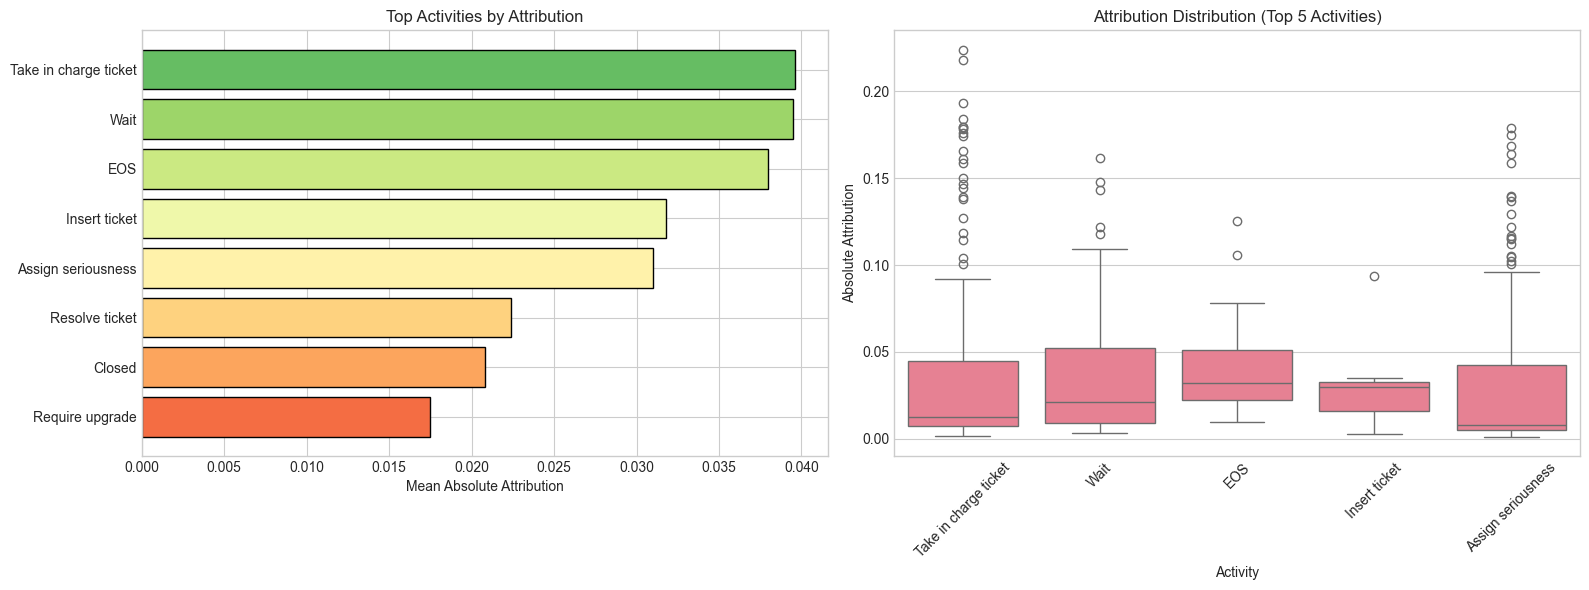

In [10]:
def analyze_feature_values(df, feature_name, top_n=15):
    """Analyze attribution patterns for a feature's values."""
    
    # Aggregate by value
    value_stats = df.groupby('value').agg({
        'abs_attribution': ['mean', 'std', 'sum', 'count'],
        'attribution': ['mean', 'std'],
        'quality': 'mean'
    }).round(4)
    
    value_stats.columns = ['_'.join(col).strip() for col in value_stats.columns]
    value_stats = value_stats.rename(columns={
        'abs_attribution_mean': 'mean_abs_attr',
        'abs_attribution_std': 'std_abs_attr',
        'abs_attribution_sum': 'total_attr',
        'abs_attribution_count': 'occurrences',
        'attribution_mean': 'mean_attr',
        'attribution_std': 'std_attr',
        'quality_mean': 'mean_quality'
    })
    
    value_stats = value_stats.sort_values('mean_abs_attr', ascending=False)
    
    return value_stats

# Analyze Activity
if 'Activity' in value_attr_dfs and len(value_attr_dfs['Activity']) > 0:
    activity_stats = analyze_feature_values(value_attr_dfs['Activity'], 'Activity')
    
    print("ACTIVITY ATTRIBUTION RANKING")
    print("=" * 80)
    print(activity_stats.head(20).to_string())
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top activities by mean attribution
    ax1 = axes[0]
    top_activities = activity_stats.head(15)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_activities)))
    ax1.barh(range(len(top_activities)), top_activities['mean_abs_attr'], color=colors, edgecolor='black')
    ax1.set_yticks(range(len(top_activities)))
    ax1.set_yticklabels(top_activities.index)
    ax1.set_xlabel('Mean Absolute Attribution')
    ax1.set_title('Top Activities by Attribution')
    ax1.invert_yaxis()
    
    # Attribution distribution for top activities
    ax2 = axes[1]
    top_5_activities = activity_stats.head(5).index.tolist()
    data_to_plot = value_attr_dfs['Activity'][value_attr_dfs['Activity']['value'].isin(top_5_activities)]
    sns.boxplot(data=data_to_plot, x='value', y='abs_attribution', ax=ax2, order=top_5_activities)
    ax2.set_xlabel('Activity')
    ax2.set_ylabel('Absolute Attribution')
    ax2.set_title('Attribution Distribution (Top 5 Activities)')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

### 5.2 Resource Attribution Breakdown

RESOURCE ATTRIBUTION RANKING
          mean_abs_attr  std_abs_attr  total_attr  occurrences  mean_attr  std_attr  mean_quality
value                                                                                            
Value 18         0.0634        0.0298      0.1901            3     0.0634    0.0298        0.0000
Value 19         0.0293        0.0335      0.0587            2     0.0293    0.0335        2.0000
Value 11         0.0234        0.0098      0.2803           12     0.0234    0.0098        2.9167
Value 7          0.0218        0.0139      0.0872            4     0.0218    0.0139        0.5000
Value 8          0.0197        0.0156      0.6107           31     0.0197    0.0156        0.8710
Value 4          0.0165        0.0189      0.8732           53     0.0165    0.0189        1.1509
Value 16         0.0158        0.0256      0.0949            6     0.0158    0.0256        0.8333
Value 14         0.0141        0.0152      0.3956           28     0.0141    0.0152      

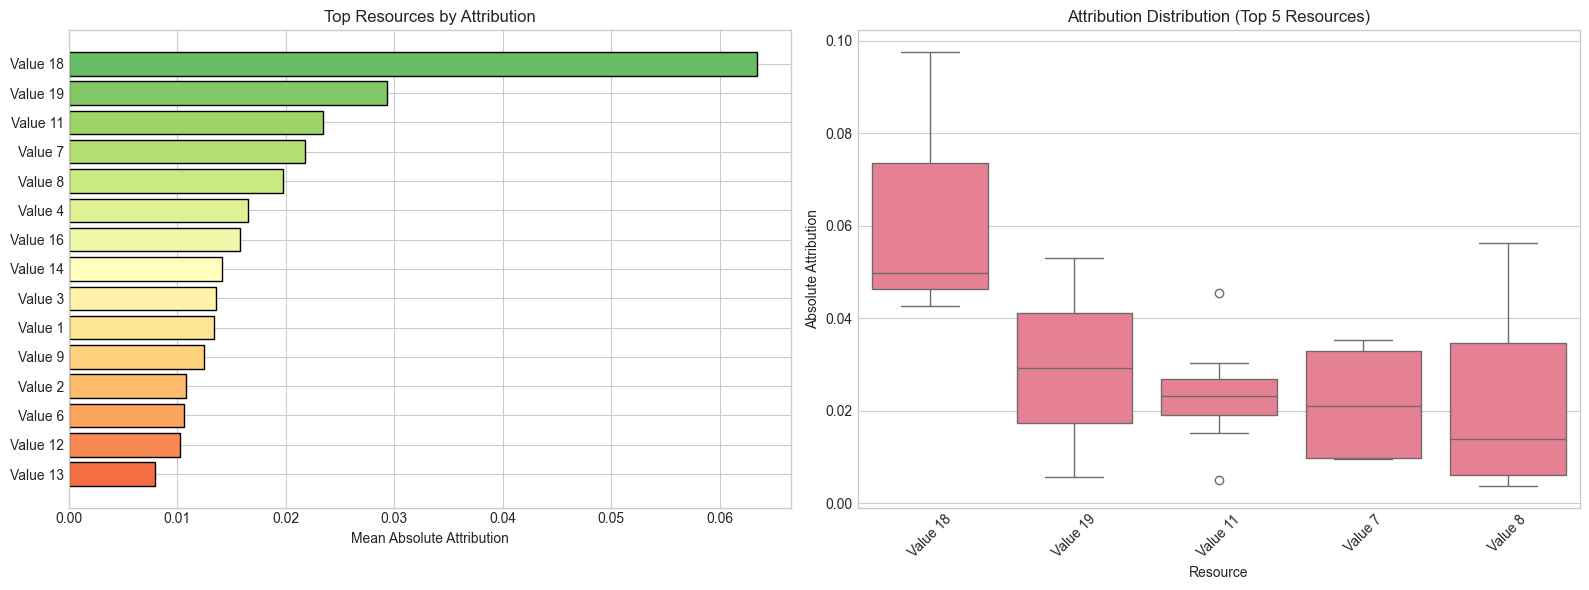

In [11]:
if 'Resource' in value_attr_dfs and len(value_attr_dfs['Resource']) > 0:
    resource_stats = analyze_feature_values(value_attr_dfs['Resource'], 'Resource')
    
    print("RESOURCE ATTRIBUTION RANKING")
    print("=" * 80)
    print(resource_stats.head(20).to_string())
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1 = axes[0]
    top_resources = resource_stats.head(15)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_resources)))
    ax1.barh(range(len(top_resources)), top_resources['mean_abs_attr'], color=colors, edgecolor='black')
    ax1.set_yticks(range(len(top_resources)))
    ax1.set_yticklabels(top_resources.index)
    ax1.set_xlabel('Mean Absolute Attribution')
    ax1.set_title('Top Resources by Attribution')
    ax1.invert_yaxis()
    
    ax2 = axes[1]
    top_5_resources = resource_stats.head(5).index.tolist()
    data_to_plot = value_attr_dfs['Resource'][value_attr_dfs['Resource']['value'].isin(top_5_resources)]
    sns.boxplot(data=data_to_plot, x='value', y='abs_attribution', ax=ax2, order=top_5_resources)
    ax2.set_xlabel('Resource')
    ax2.set_ylabel('Absolute Attribution')
    ax2.set_title('Attribution Distribution (Top 5 Resources)')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

### 5.3 Customer Attribution Breakdown

CUSTOMER ATTRIBUTION RANKING
           mean_abs_attr  std_abs_attr  total_attr  occurrences  mean_attr  std_attr  mean_quality
value                                                                                             
Value 100         0.0808        0.0162      0.1615            2     0.0808    0.0162        0.0000
Value 86          0.0802        0.0366      0.4009            5     0.0802    0.0366        0.0000
Value 64          0.0695           NaN      0.0695            1     0.0695       NaN        2.0000
Value 271         0.0682        0.0145      0.1365            2     0.0682    0.0145        0.0000
Value 53          0.0619        0.0239      0.2478            4     0.0619    0.0239        2.0000
Value 92          0.0609           NaN      0.0609            1     0.0609       NaN        1.0000
Value 224         0.0571        0.0136      0.1142            2     0.0571    0.0136        0.0000
Value 7           0.0518        0.0152      0.1553            3     0.0518    0.

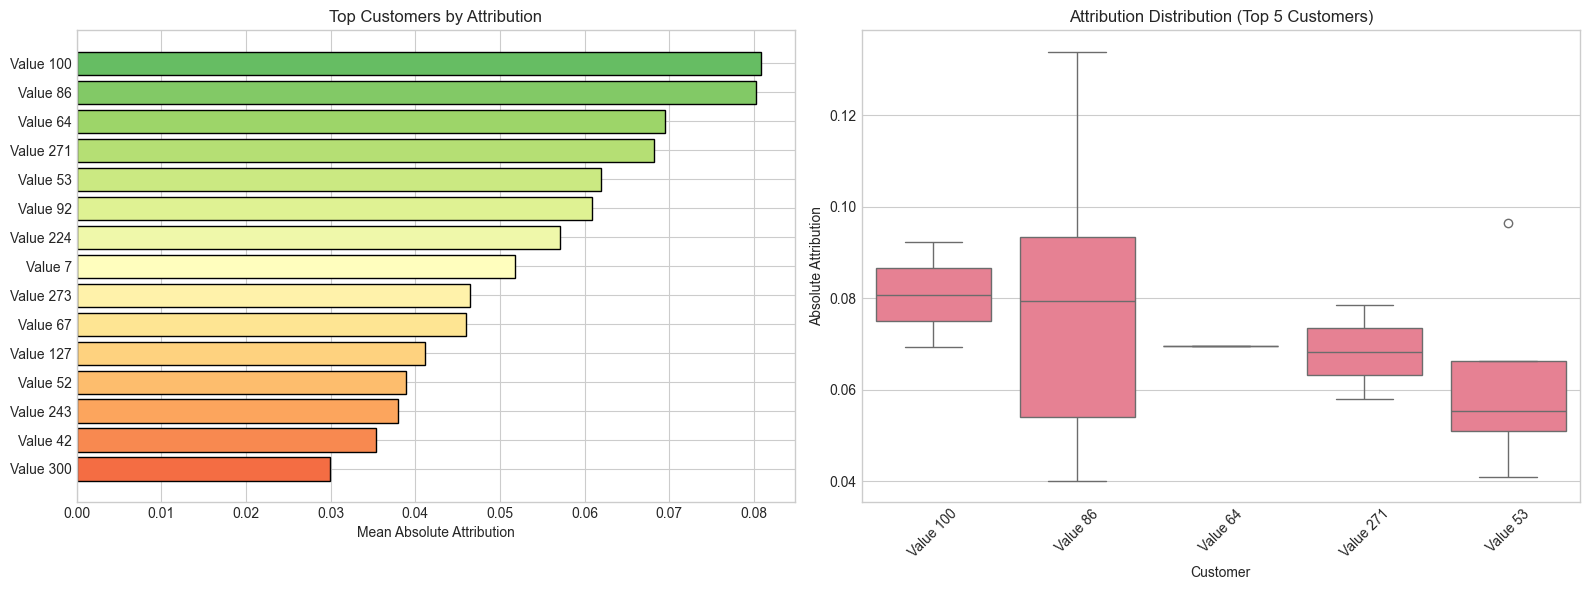

In [12]:
if 'customer' in value_attr_dfs and len(value_attr_dfs['customer']) > 0:
    customer_stats = analyze_feature_values(value_attr_dfs['customer'], 'customer')
    
    print("CUSTOMER ATTRIBUTION RANKING")
    print("=" * 80)
    print(customer_stats.head(20).to_string())
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1 = axes[0]
    top_customers = customer_stats.head(15)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_customers)))
    ax1.barh(range(len(top_customers)), top_customers['mean_abs_attr'], color=colors, edgecolor='black')
    ax1.set_yticks(range(len(top_customers)))
    ax1.set_yticklabels(top_customers.index)
    ax1.set_xlabel('Mean Absolute Attribution')
    ax1.set_title('Top Customers by Attribution')
    ax1.invert_yaxis()
    
    ax2 = axes[1]
    top_5_customers = customer_stats.head(5).index.tolist()
    data_to_plot = value_attr_dfs['customer'][value_attr_dfs['customer']['value'].isin(top_5_customers)]
    sns.boxplot(data=data_to_plot, x='value', y='abs_attribution', ax=ax2, order=top_5_customers)
    ax2.set_xlabel('Customer')
    ax2.set_ylabel('Absolute Attribution')
    ax2.set_title('Attribution Distribution (Top 5 Customers)')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

### 5.4 Variant Index Attribution Breakdown

VARIANT INDEX ATTRIBUTION RANKING
       mean_abs_attr  std_abs_attr  total_attr  occurrences  mean_attr  std_attr  mean_quality
value                                                                                         
14.0          0.2314        0.0563      0.4627            2     0.2314    0.0563        0.0000
32.0          0.1781        0.0553      0.7124            4     0.1781    0.0553        2.0000
58.0          0.1587        0.0827      0.7934            5     0.1587    0.0827        0.0000
31.0          0.1237        0.0184      0.2475            2     0.1237    0.0184        0.0000
37.0          0.1118        0.0518      1.0058            9     0.1118    0.0518        3.8889
47.0          0.0918        0.0796      1.2857           14     0.0918    0.0796        0.2857
41.0          0.0729        0.0200      0.2188            3     0.0729    0.0200        1.0000
83.0          0.0524        0.0553      1.1011           21     0.0524    0.0553        0.9524
2.0           0.

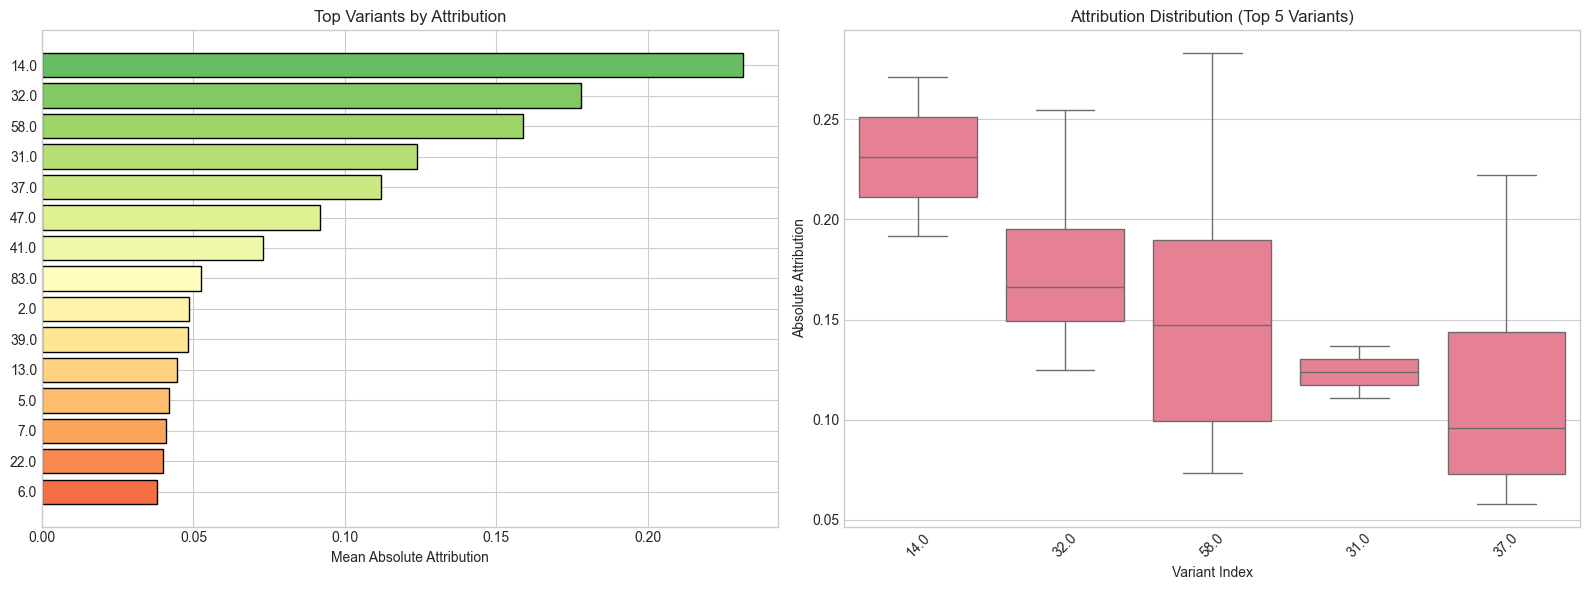

In [13]:
if 'Variant index' in value_attr_dfs and len(value_attr_dfs['Variant index']) > 0:
    variant_stats = analyze_feature_values(value_attr_dfs['Variant index'], 'Variant index')
    
    print("VARIANT INDEX ATTRIBUTION RANKING")
    print("=" * 80)
    print(variant_stats.head(20).to_string())
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1 = axes[0]
    top_variants = variant_stats.head(15)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_variants)))
    ax1.barh(range(len(top_variants)), top_variants['mean_abs_attr'], color=colors, edgecolor='black')
    ax1.set_yticks(range(len(top_variants)))
    ax1.set_yticklabels(top_variants.index)
    ax1.set_xlabel('Mean Absolute Attribution')
    ax1.set_title('Top Variants by Attribution')
    ax1.invert_yaxis()
    
    ax2 = axes[1]
    top_5_variants = variant_stats.head(5).index.tolist()
    data_to_plot = value_attr_dfs['Variant index'][value_attr_dfs['Variant index']['value'].isin(top_5_variants)]
    sns.boxplot(data=data_to_plot, x='value', y='abs_attribution', ax=ax2, order=top_5_variants)
    ax2.set_xlabel('Variant Index')
    ax2.set_ylabel('Absolute Attribution')
    ax2.set_title('Attribution Distribution (Top 5 Variants)')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 6. Position Analysis: Does Attribution Depend on Where the Value Appears?

Do values get more attribution when they appear at the beginning vs end of the prefix?

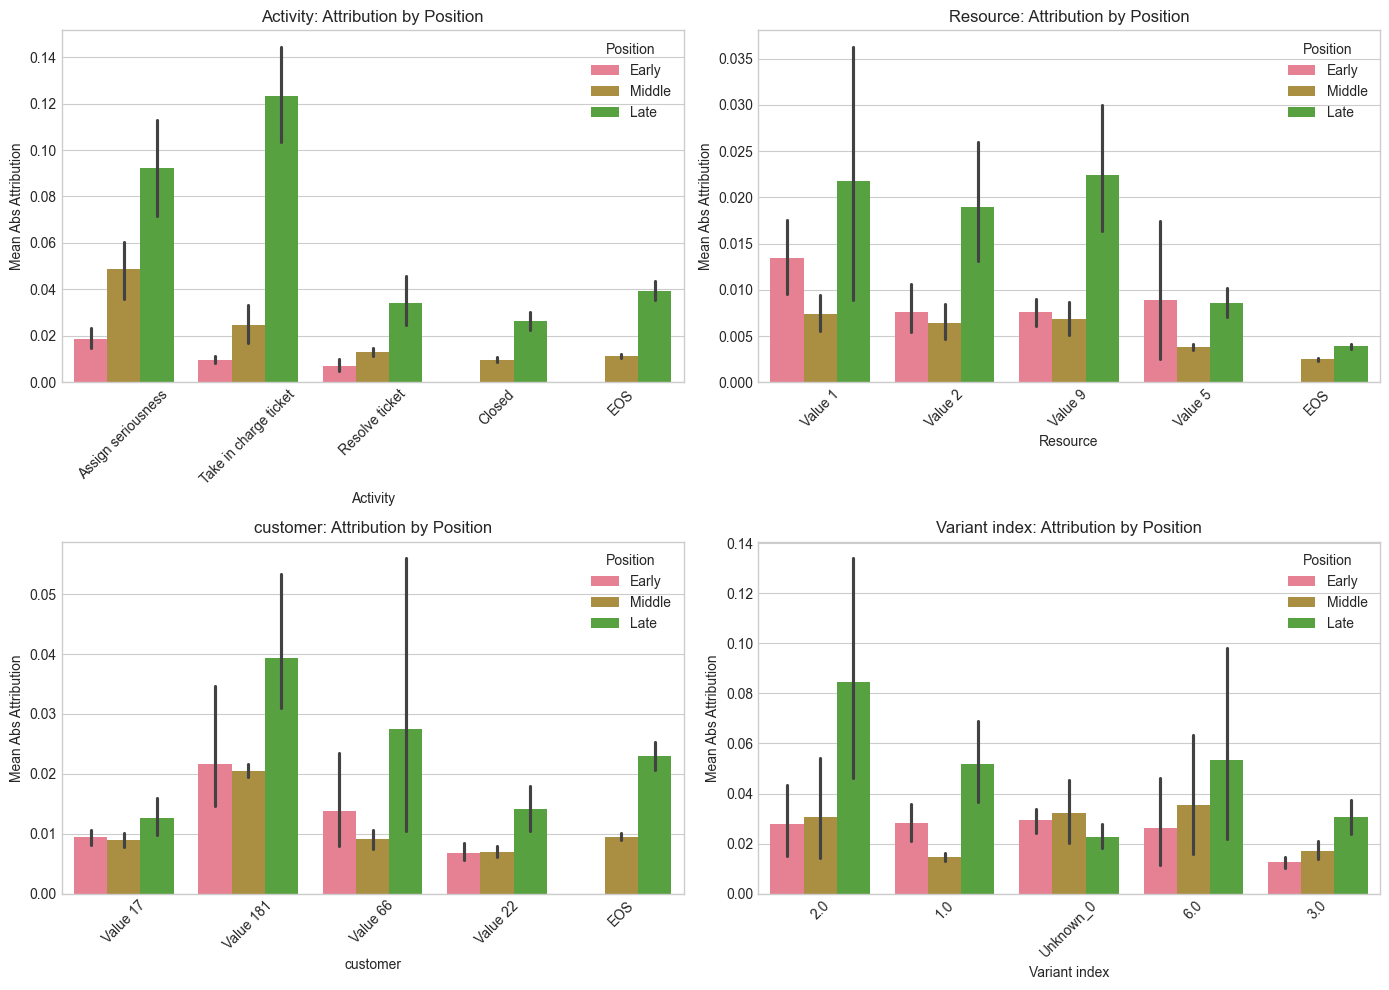

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feat_name in enumerate(FEATURES_TO_ANALYZE[:4]):
    ax = axes[idx // 2, idx % 2]
    
    if feat_name not in value_attr_dfs or len(value_attr_dfs[feat_name]) == 0:
        ax.set_title(f'{feat_name}: No data')
        continue
    
    df = value_attr_dfs[feat_name]
    
    # Bin by position
    df['position_bin'] = pd.cut(df['position'], bins=[0, 0.33, 0.66, 1.0], 
                                 labels=['Early', 'Middle', 'Late'], include_lowest=True)
    
    # Get top 5 values by occurrence
    top_values = df['value'].value_counts().head(5).index.tolist()
    df_top = df[df['value'].isin(top_values)]
    
    # Plot
    sns.barplot(data=df_top, x='value', y='abs_attribution', hue='position_bin', ax=ax)
    ax.set_xlabel(feat_name)
    ax.set_ylabel('Mean Abs Attribution')
    ax.set_title(f'{feat_name}: Attribution by Position')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Position', loc='upper right')

plt.tight_layout()
plt.show()

## 7. Attribution vs Prediction Quality

Do certain values get more attribution in good vs poor predictions?

ACTIVITY: Attribution in Good vs Poor Predictions
(Positive diff = more attribution in poor predictions)
quality_bucket             Good      Poor      diff
value                                              
Assign seriousness     0.025406  0.038447  0.013040
Closed                 0.018940  0.023914  0.004974
Take in charge ticket  0.038020  0.042408  0.004388
EOS                    0.038505  0.037081 -0.001424
Require upgrade        0.018946  0.015387 -0.003559
Resolve ticket         0.024341  0.018623 -0.005718
Wait                   0.042927  0.031482 -0.011445
Insert ticket          0.040095  0.020826 -0.019269


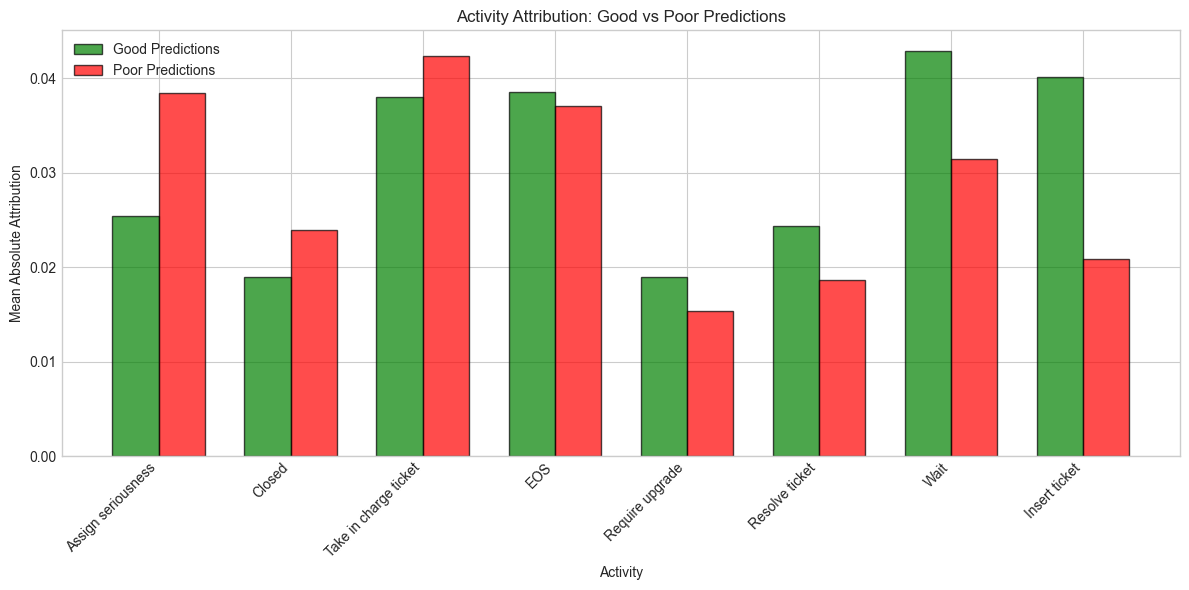

In [15]:
def compare_by_quality(df, feat_name, top_n=10):
    """Compare attribution for top values between good and poor predictions."""
    
    # Define quality buckets
    df = df.copy()
    median_quality = df['quality'].median()
    df['quality_bucket'] = df['quality'].apply(lambda x: 'Good' if x <= median_quality else 'Poor')
    
    # Get top values
    top_values = df.groupby('value')['abs_attribution'].mean().nlargest(top_n).index.tolist()
    df_top = df[df['value'].isin(top_values)]
    
    # Aggregate
    comparison = df_top.groupby(['value', 'quality_bucket'])['abs_attribution'].mean().unstack(fill_value=0)
    comparison['diff'] = comparison.get('Poor', 0) - comparison.get('Good', 0)
    comparison = comparison.sort_values('diff', ascending=False)
    
    return comparison

# Compare for Activity
if 'Activity' in value_attr_dfs and len(value_attr_dfs['Activity']) > 0:
    activity_quality = compare_by_quality(value_attr_dfs['Activity'], 'Activity')
    
    print("ACTIVITY: Attribution in Good vs Poor Predictions")
    print("=" * 60)
    print("(Positive diff = more attribution in poor predictions)")
    print(activity_quality.to_string())
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = range(len(activity_quality))
    width = 0.35
    
    ax.bar([i - width/2 for i in x], activity_quality.get('Good', 0), width, 
           label='Good Predictions', color='green', alpha=0.7, edgecolor='black')
    ax.bar([i + width/2 for i in x], activity_quality.get('Poor', 0), width,
           label='Poor Predictions', color='red', alpha=0.7, edgecolor='black')
    
    ax.set_xticks(x)
    ax.set_xticklabels(activity_quality.index, rotation=45, ha='right')
    ax.set_xlabel('Activity')
    ax.set_ylabel('Mean Absolute Attribution')
    ax.set_title('Activity Attribution: Good vs Poor Predictions')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

## 8. Cross-Feature Heatmap: Value Co-occurrence with High Attribution

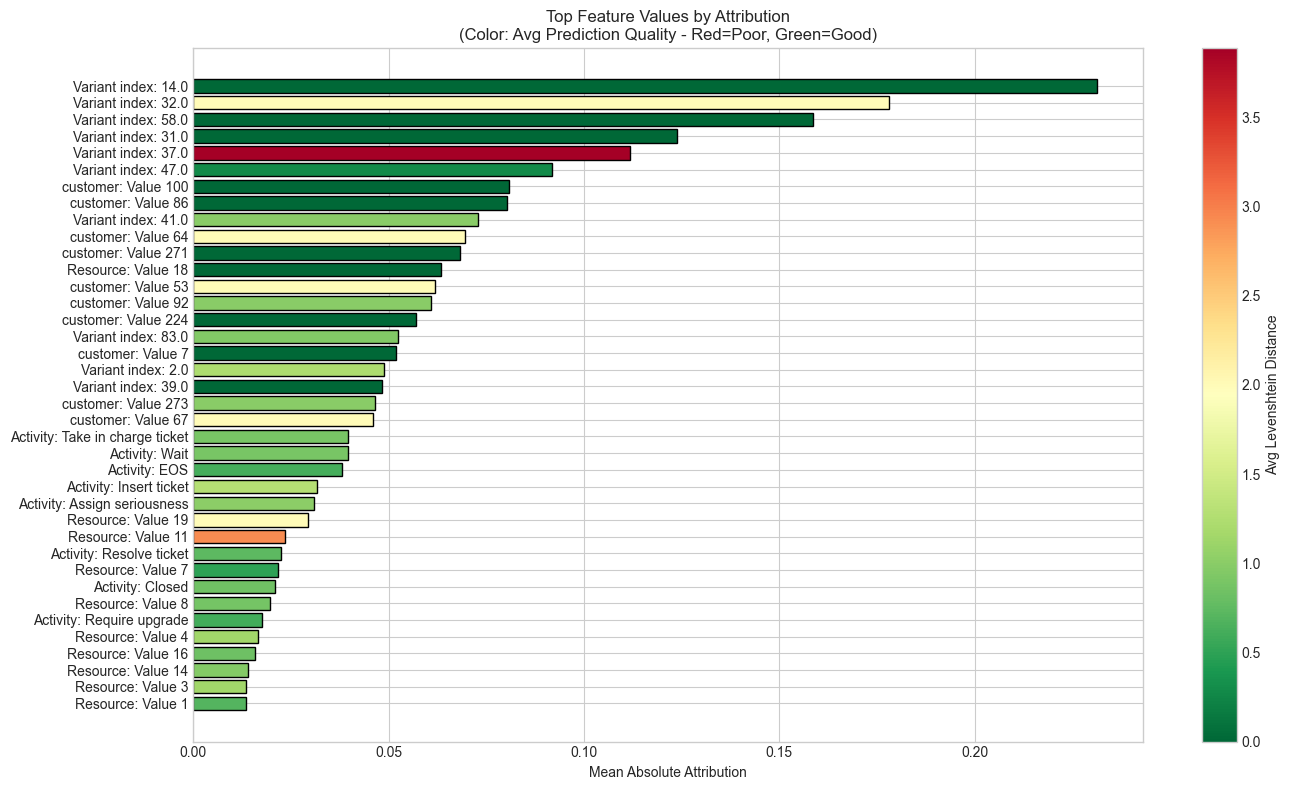

In [16]:
# Create summary table of top values per feature
summary_data = []

for feat_name in FEATURES_TO_ANALYZE:
    if feat_name not in value_attr_dfs or len(value_attr_dfs[feat_name]) == 0:
        continue
    
    stats = analyze_feature_values(value_attr_dfs[feat_name], feat_name)
    
    for value, row in stats.head(10).iterrows():
        summary_data.append({
            'Feature': feat_name,
            'Value': value,
            'Mean Attribution': row['mean_abs_attr'],
            'Occurrences': row['occurrences'],
            'Avg Quality': row['mean_quality']
        })

summary_df = pd.DataFrame(summary_data)

# Pivot for heatmap
if len(summary_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Create a combined label
    summary_df['Label'] = summary_df['Feature'] + ': ' + summary_df['Value'].astype(str)
    
    # Sort by attribution
    summary_df = summary_df.sort_values('Mean Attribution', ascending=True)
    
    colors = plt.cm.RdYlGn_r(summary_df['Avg Quality'] / summary_df['Avg Quality'].max())
    
    ax.barh(summary_df['Label'], summary_df['Mean Attribution'], color=colors, edgecolor='black')
    ax.set_xlabel('Mean Absolute Attribution')
    ax.set_title('Top Feature Values by Attribution\n(Color: Avg Prediction Quality - Red=Poor, Green=Good)')
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', 
                               norm=plt.Normalize(0, summary_df['Avg Quality'].max()))
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Avg Levenshtein Distance')
    
    plt.tight_layout()
    plt.show()

## 9. Summary: High vs Low Attribution Values

In [17]:
print("=" * 80)
print("FEATURE VALUE ATTRIBUTION SUMMARY")
print("=" * 80)

for feat_name in FEATURES_TO_ANALYZE:
    if feat_name not in value_attr_dfs or len(value_attr_dfs[feat_name]) == 0:
        continue
    
    stats = analyze_feature_values(value_attr_dfs[feat_name], feat_name)
    
    print(f"\n{feat_name.upper()}")
    print("-" * 40)
    
    # High attribution values
    print("HIGH Attribution (model pays attention):")
    for val in stats.head(5).index:
        row = stats.loc[val]
        print(f"  - {val}: {row['mean_abs_attr']:.4f} (n={int(row['occurrences'])})")
    
    # Low attribution values
    print("\nLOW Attribution (model ignores):")
    for val in stats.tail(5).index:
        row = stats.loc[val]
        print(f"  - {val}: {row['mean_abs_attr']:.4f} (n={int(row['occurrences'])})")

print("\n" + "=" * 80)

FEATURE VALUE ATTRIBUTION SUMMARY

ACTIVITY
----------------------------------------
HIGH Attribution (model pays attention):
  - Take in charge ticket: 0.0396 (n=144)
  - Wait: 0.0395 (n=47)
  - EOS: 0.0380 (n=99)
  - Insert ticket: 0.0318 (n=7)
  - Assign seriousness: 0.0310 (n=181)

LOW Attribution (model ignores):
  - Insert ticket: 0.0318 (n=7)
  - Assign seriousness: 0.0310 (n=181)
  - Resolve ticket: 0.0224 (n=111)
  - Closed: 0.0208 (n=82)
  - Require upgrade: 0.0175 (n=5)

RESOURCE
----------------------------------------
HIGH Attribution (model pays attention):
  - Value 18: 0.0634 (n=3)
  - Value 19: 0.0293 (n=2)
  - Value 11: 0.0234 (n=12)
  - Value 7: 0.0218 (n=4)
  - Value 8: 0.0197 (n=31)

LOW Attribution (model ignores):
  - Value 13: 0.0079 (n=27)
  - Value 5: 0.0070 (n=73)
  - EOS: 0.0038 (n=99)
  - Value 15: 0.0027 (n=3)
  - Value 17: 0.0024 (n=1)

CUSTOMER
----------------------------------------
HIGH Attribution (model pays attention):
  - Value 100: 0.0808 (n=2)
 